In [1]:
#  Lets begin Diabetes prediction for health domain EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint

In [2]:
# File Paths for train and test data
BASE_PATH = r"../playground-series-s5e12/"
TRAIN_PATH = BASE_PATH + "train.csv"
TEST_PATH =  BASE_PATH + "test.csv"

In [3]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

In [4]:
train.head(10)

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0
5,5,42,1,100,4.4,6.4,5.3,25.5,0.84,111,...,Female,White,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
6,6,41,2,148,3.4,5.6,3.7,27.9,0.89,130,...,Female,White,Graduate,Lower-Middle,Current,Employed,0,0,0,1.0
7,7,51,3,102,4.0,7.3,5.5,27.1,0.83,125,...,Male,Asian,Highschool,Low,Never,Employed,1,0,0,1.0
8,8,34,2,44,2.7,7.0,7.9,22.6,0.81,120,...,Male,White,Highschool,Lower-Middle,Never,Employed,0,0,0,0.0
9,9,44,1,36,5.8,5.7,6.6,29.3,0.88,110,...,Male,Hispanic,Highschool,Middle,Never,Employed,1,0,0,1.0


### A Classification probelem

In [5]:
train.dtypes

id                                      int64
age                                     int64
alcohol_consumption_per_week            int64
physical_activity_minutes_per_week      int64
diet_score                            float64
sleep_hours_per_day                   float64
screen_time_hours_per_day             float64
bmi                                   float64
waist_to_hip_ratio                    float64
systolic_bp                             int64
diastolic_bp                            int64
heart_rate                              int64
cholesterol_total                       int64
hdl_cholesterol                         int64
ldl_cholesterol                         int64
triglycerides                           int64
gender                                 object
ethnicity                              object
education_level                        object
income_level                           object
smoking_status                         object
employment_status                 

In [6]:
for i in train.columns:
    check_col = train[i]
    print("#" * 20)
    print((i).upper(), check_col.dtype)
    # if check_col.dtype == "object":
    print("Unique values: ")
    pprint(check_col.unique())

####################
ID int64
Unique values: 
array([     0,      1,      2, ..., 699997, 699998, 699999],
      shape=(700000,))
####################
AGE int64
Unique values: 
array([31, 50, 32, 54, 42, 41, 51, 34, 44, 47, 63, 40, 57, 49, 43, 70, 53,
       45, 59, 52, 73, 61, 33, 38, 20, 56, 46, 48, 62, 39, 36, 21, 22, 55,
       30, 67, 25, 60, 28, 26, 65, 74, 37, 68, 23, 58, 84, 27, 64, 66, 35,
       72, 29, 79, 75, 80, 71, 77, 24, 78, 69, 19, 82, 81, 76, 83, 87, 85,
       86, 88, 89])
####################
ALCOHOL_CONSUMPTION_PER_WEEK int64
Unique values: 
array([1, 2, 3, 4, 5, 6, 7, 8, 9])
####################
PHYSICAL_ACTIVITY_MINUTES_PER_WEEK int64
Unique values: 
array([ 45,  73, 158,  77,  55, 100, 148, 102,  44,  36, 239,  58, 109,
       251,  57,  99,  53,  54,  94,  29,  72,  46,  52, 118,  82, 140,
        47,  59,  92,  32,  28,  70,  34,  83,  91,  98, 217,  84, 135,
        41,  43, 113,  90,  37, 142, 174, 144, 196,   4,  42, 166,  65,
        85, 194, 110,  64,  48

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

In [8]:
# Category Cols
# ALCOHOL_CONSUMPTION_PER_WEEK: [1, 2, 3, 4, 5, 6, 7, 8, 9],
# GENDER: ['Female', 'Male', 'Other'],
# ETHNICITY: ['Hispanic', 'White', 'Asian', 'Black', 'Other'],
# EDUCATION_LEVEL: ['Highschool', 'Graduate', 'Postgraduate', 'No formal'], 
# INCOME_LEVEL: ['Lower-Middle', 'Upper-Middle', 'Low', 'Middle', 'High'],
# SMOKING_STATUS: ['Current', 'Never', 'Former'],
# EMPLOYMENT_STATUS: ['Employed', 'Retired', 'Student', 'Unemployed'],
# FAMILY_HISTORY_DIABETES: [0,1],
# HYPERTENSION_HISTORY: [0,1],
# CARDIOVASCULAR_HISTORY: [0,1],
# DIAGNOSED_DIABETES: [1,0]

In [9]:
pd.read_csv(TRAIN_PATH).describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,349999.500000,50.359734,2.072411,80.230803,5.963695,7.002200,6.012733,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,53.823214,102.905854,123.081850,0.149401,0.181990,0.030324,0.623296
std,202072.738554,11.655520,1.048189,51.195071,1.463336,0.901907,2.022707,2.860705,0.037980,11.010390,6.825775,6.938722,16.730832,8.266545,19.022416,24.739397,0.356484,0.385837,0.171478,0.484560
min,0.000000,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,174999.750000,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,349999.500000,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,524999.250000,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,699999.000000,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
num_cols = []
other_cols = []
for i in train.columns:
    if train[i].dtype in ("int64", "float64"):
        num_cols.append(i)
    else:
        other_cols.append(i)

print(num_cols)
print(other_cols)

['id', 'age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'diagnosed_diabetes']
['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']


In [11]:
NUM_COLS = [
    'age', 
    'alcohol_consumption_per_week', 
    'physical_activity_minutes_per_week', 
    'diet_score', 
    'sleep_hours_per_day', 
    'screen_time_hours_per_day', 
    'bmi', 
    'waist_to_hip_ratio', 
    'systolic_bp', 
    'diastolic_bp', 
    'heart_rate', 
    'cholesterol_total', 
    'hdl_cholesterol', 
    'ldl_cholesterol', 
    'triglycerides', 
]

CAT_COLS = [
    'gender',
    'ethnicity', 
    'education_level', 
    'income_level', 
    'smoking_status', 
    'employment_status',
    'family_history_diabetes', # Binary 1/0
    'hypertension_history', # Binary 1/0
    'cardiovascular_history', # Binary 1/0
    'diagnosed_diabetes' # Binary 1/0
]

TARGET = 'diagnosed_diabetes'


In [28]:
import pandas as pd
import numpy as np
from scipy.stats import pointbiserialr
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.preprocessing import LabelEncoder


def analyze_feature_target_relationship(X, y):
    """
    Analyze the relationship between each feature and a binary classification target.
    Works for both numeric and categorical columns.

    Returns:
        dict containing:
            - point_biserial_df
            - mi_numeric_df
            - chi_square_df
            - mi_categorical_df
            - combined_ranking_df
    """

    # Separate columns
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

    results = {}

    # =====================
    # 1. Point-Biserial (Numeric ↔ Target)
    # =====================
    pb_results = {}
    for col in num_cols:
        corr, p_value = pointbiserialr(X[col], y)
        pb_results[col] = {"corr": corr, "p_value": p_value}

    point_biserial_df = pd.DataFrame(pb_results).T.sort_values("corr", ascending=False)
    results["point_biserial_df"] = point_biserial_df

    # =====================
    # 2. Mutual Information (Numeric)
    # =====================
    if len(num_cols) > 0:
        mi_numeric = mutual_info_classif(X[num_cols], y)
        mi_numeric_df = pd.DataFrame({
            "feature": num_cols,
            "mutual_info": mi_numeric
        }).sort_values("mutual_info", ascending=False)
    else:
        mi_numeric_df = pd.DataFrame()
    results["mi_numeric_df"] = mi_numeric_df

    # =====================
    # 3. Chi-square Test (Categorical)
    # =====================
    if len(cat_cols) > 0:
        X_cat_encoded = X[cat_cols].apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))
        chi_scores, p_vals = chi2(X_cat_encoded, y)

        chi_square_df = pd.DataFrame({
            "feature": cat_cols,
            "chi_square": chi_scores,
            "p_value": p_vals
        }).sort_values("chi_square", ascending=False)
    else:
        chi_square_df = pd.DataFrame()
    results["chi_square_df"] = chi_square_df

    # =====================
    # 4. Mutual Information (Categorical)
    # =====================
    if len(cat_cols) > 0:
        mi_cat = mutual_info_classif(X_cat_encoded, y)
        mi_categorical_df = pd.DataFrame({
            "feature": cat_cols,
            "mutual_info": mi_cat
        }).sort_values("mutual_info", ascending=False)
    else:
        mi_categorical_df = pd.DataFrame()
    results["mi_categorical_df"] = mi_categorical_df

    # =====================
    # 5. Combined Ranking
    # =====================
    combined = []

    # Add point biserial
    for feature, row in point_biserial_df.iterrows():
        combined.append([feature, abs(row["corr"]), "point_biserial"])

    # Add MI numeric
    for _, row in mi_numeric_df.iterrows():
        combined.append([row["feature"], row["mutual_info"], "mi_numeric"])

    # Add chi-square
    for _, row in chi_square_df.iterrows():
        combined.append([row["feature"], row["chi_square"], "chi_square"])

    # Add MI categorical
    for _, row in mi_categorical_df.iterrows():
        combined.append([row["feature"], row["mutual_info"], "mi_categorical"])

    combined_df = pd.DataFrame(combined, columns=["feature", "score", "method"])
    combined_ranking_df = combined_df.sort_values("score", ascending=False).reset_index(drop=True)

    results["combined_ranking_df"] = combined_ranking_df

    return results
results = analyze_feature_target_relationship(train[NUM_COLS + CAT_COLS], train[TARGET])

print("=== Point-Biserial (Numeric) ===")
display(results["point_biserial_df"])

print("=== Mutual Information (Numeric) ===")
display(results["mi_numeric_df"])

print("=== Chi-Square (Categorical) ===")
display(results["chi_square_df"])

print("=== Mutual Information (Categorical) ===")
display(results["mi_categorical_df"])

print("=== Combined Ranking ===")
display(results["combined_ranking_df"])


=== Point-Biserial (Numeric) ===


,corr,p_value
diagnosed_diabetes,1.000000,0.000000e+00
family_history_diabetes,0.211064,0.000000e+00
age,0.161162,0.000000e+00
systolic_bp,0.107132,0.000000e+00
bmi,0.105580,0.000000e+00
ldl_cholesterol,0.102771,0.000000e+00
triglycerides,0.090635,0.000000e+00
cholesterol_total,0.088112,0.000000e+00
waist_to_hip_ratio,0.081050,0.000000e+00
diastolic_bp,0.036271,2.080722e-202


=== Mutual Information (Numeric) ===


,feature,mutual_info
18,diagnosed_diabetes,0.792748
2,physical_activity_minutes_per_week,0.035282
15,family_history_diabetes,0.034001
1,alcohol_consumption_per_week,0.015987
0,age,0.015618
14,triglycerides,0.009561
7,waist_to_hip_ratio,0.009236
16,hypertension_history,0.008675
8,systolic_bp,0.008235
6,bmi,0.007458


=== Chi-Square (Categorical) ===


,feature,chi_square,p_value
2,education_level,23.471812,0.000001
3,income_level,11.513910,0.000691
5,employment_status,10.026704,0.001543
0,gender,2.642365,0.104049
4,smoking_status,0.116292,0.733091
1,ethnicity,0.054494,0.815421


=== Mutual Information (Categorical) ===


,feature,mutual_info
4,smoking_status,0.059448
1,ethnicity,0.041990
2,education_level,0.032826
3,income_level,0.029202
0,gender,0.028915
5,employment_status,0.005231


=== Combined Ranking ===


,feature,score,method
0,education_level,23.471812,chi_square
1,income_level,11.513910,chi_square
2,employment_status,10.026704,chi_square
3,gender,2.642365,chi_square
4,diagnosed_diabetes,1.000000,point_biserial
5,diagnosed_diabetes,0.792748,mi_numeric
6,family_history_diabetes,0.211064,point_biserial
7,physical_activity_minutes_per_week,0.169789,point_biserial
8,age,0.161162,point_biserial
9,smoking_status,0.116292,chi_square


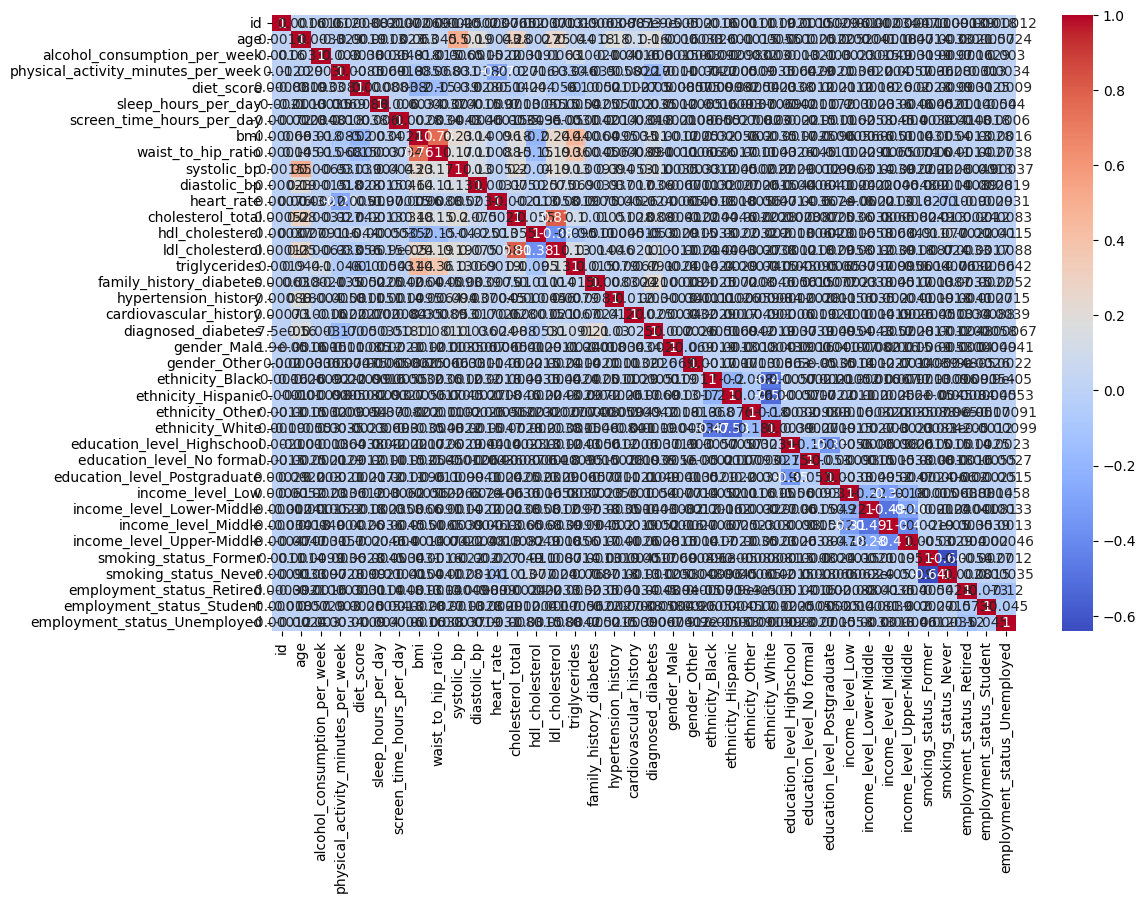

In [41]:
plt.figure(figsize=(12, 8))
df = pd.get_dummies(train, drop_first=True)
sns.heatmap(data=df.corr(), annot=True,cmap="coolwarm")
plt.show()

In [44]:
x = df.corr()["diagnosed_diabetes"]
x.sort_values()

physical_activity_minutes_per_week   -0.169789
hdl_cholesterol                      -0.053231
diet_score                           -0.050119
ethnicity_Hispanic                   -0.006880
income_level_Middle                  -0.005223
education_level_Postgraduate         -0.004916
employment_status_Retired            -0.004810
education_level_Highschool           -0.003722
income_level_Upper-Middle            -0.002805
smoking_status_Never                 -0.001232
employment_status_Unemployed         -0.000666
employment_status_Student            -0.000578
id                                   -0.000075
ethnicity_Black                       0.000510
smoking_status_Former                 0.001737
ethnicity_White                       0.001852
gender_Male                           0.001963
gender_Other                          0.002590
alcohol_consumption_per_week          0.002991
sleep_hours_per_day                   0.003509
education_level_No formal             0.003892
ethnicity_Oth

In [45]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

In [46]:
train.describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,349999.500000,50.359734,2.072411,80.230803,5.963695,7.002200,6.012733,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,53.823214,102.905854,123.081850,0.149401,0.181990,0.030324,0.623296
std,202072.738554,11.655520,1.048189,51.195071,1.463336,0.901907,2.022707,2.860705,0.037980,11.010390,6.825775,6.938722,16.730832,8.266545,19.022416,24.739397,0.356484,0.385837,0.171478,0.484560
min,0.000000,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,174999.750000,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,349999.500000,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,524999.250000,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,699999.000000,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


In [48]:
train.diagnosed_diabetes.value_counts()

diagnosed_diabetes
1.0    436307
0.0    263693
Name: count, dtype: int64

In [50]:
print(436307/263693)
print(263693/436307)

1.6546021320247408
0.6043749011590462


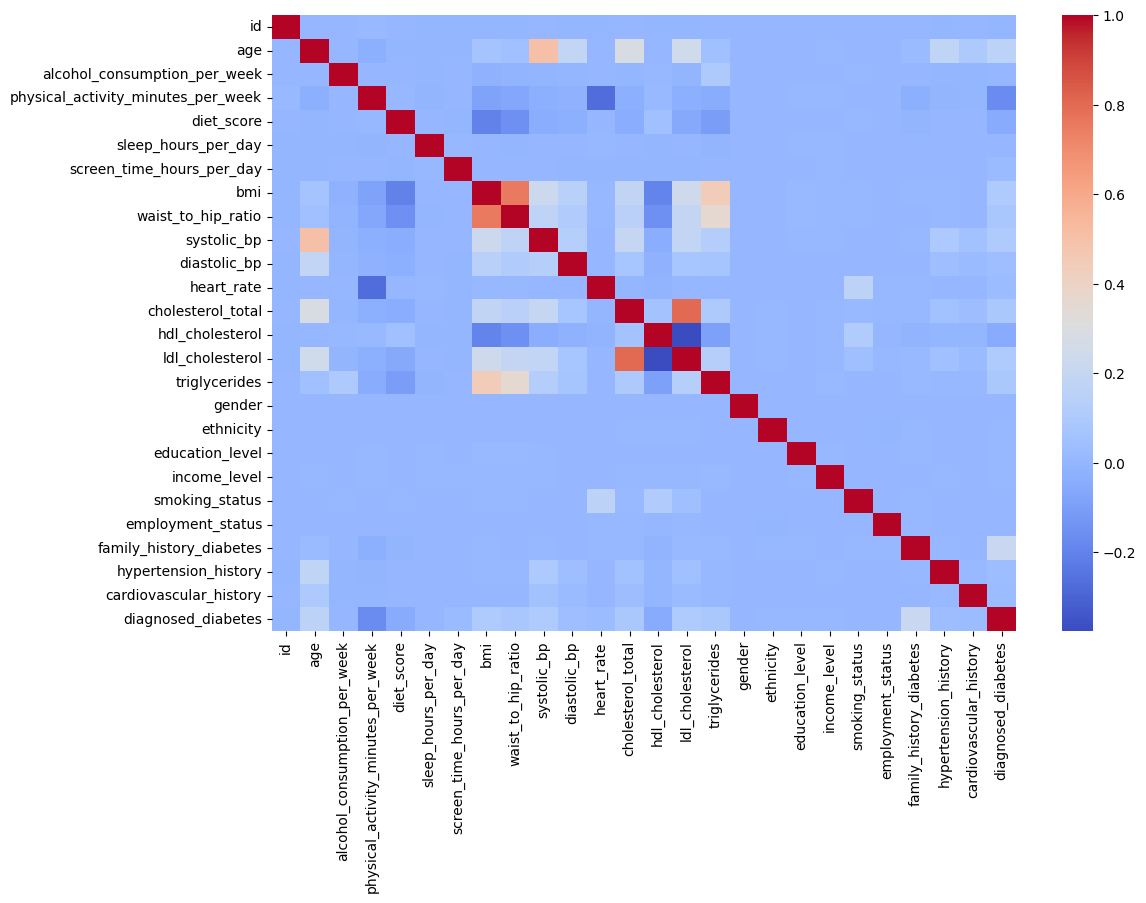

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

def correlation_ratio(categories, values):
    fcat, _ = pd.factorize(categories)
    cat_means = [values[fcat == i].mean() for i in range(len(np.unique(fcat)))]
    overall_mean = values.mean()
    numerator = sum([len(values[fcat == i]) * (cat_means[i] - overall_mean) ** 2
                     for i in range(len(np.unique(fcat)))])
    denominator = sum((values - overall_mean) ** 2)
    return np.sqrt(numerator / denominator)

def mixed_corr(df):
    cols = df.columns
    corr = pd.DataFrame(index=cols, columns=cols, dtype=float)

    for i in cols:
        for j in cols:
            if df[i].dtype in ['float', 'int'] and df[j].dtype in ['float', 'int']:
                corr.loc[i, j] = df[i].corr(df[j])
            elif df[i].dtype in ['object', 'category'] and df[j].dtype in ['object', 'category']:
                corr.loc[i, j] = cramers_v(df[i], df[j])
            else:  # mixed num-cat
                if df[i].dtype in ['object', 'category']:
                    corr.loc[i, j] = correlation_ratio(df[i], df[j])
                else:
                    corr.loc[i, j] = correlation_ratio(df[j], df[i])
    return corr

# Compute mixed correlation
corr = mixed_corr(train)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.show()


In [56]:
train.columns

Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes'],
      dtype='object')

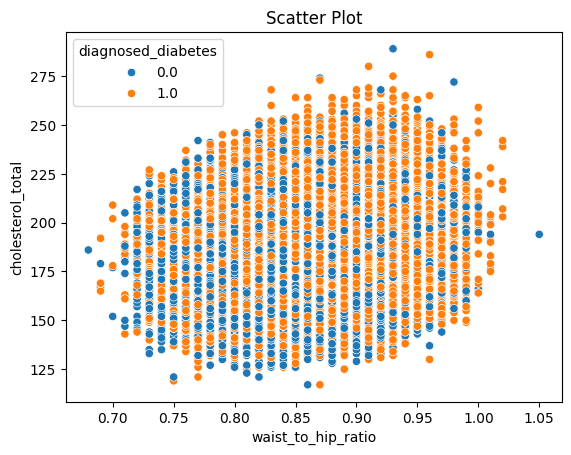

In [71]:
sns.scatterplot(data=df, x='waist_to_hip_ratio', y='cholesterol_total', hue=TARGET)
plt.title("Scatter Plot")
plt.show()


In [ ]:
sns.violinplot(data=train, x='category_col', y='numeric_col')
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(df[['num1', 'num2']])

sns.scatterplot(data=df, x='num1', y='num2', hue='cluster', palette='deep')
plt.title("K-Means Clusters")
plt.show()